# NB01: Truly Dark Gene Census

**Goal**: Define the truly dark gene set (genes that remain hypothetical after bakta v1.12.0 reannotation) and characterize how they differ from "annotation-lag" genes.

**Input**: `functional_dark_matter` project outputs (NB12 bakta enrichment)

**Key question**: Are truly dark genes structurally and evolutionarily distinct, or just a random subset of hypotheticals that bakta's databases haven't caught up to yet?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import os
import warnings
warnings.filterwarnings('ignore')

# Paths
FDM = '../../../projects/functional_dark_matter/data'
ESS = '../../../projects/essential_genome/data'
OUT = '../data'
FIG = '../figures'
os.makedirs(OUT, exist_ok=True)
os.makedirs(FIG, exist_ok=True)

plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 150, 'font.size': 10})

## 1. Load Parent Project Data

In [2]:
# Full dark gene census (57,011 genes)
census = pd.read_csv(f'{FDM}/dark_gene_census_full.tsv', sep='\t')
print(f'Total dark genes: {len(census):,}')

# Bakta annotations for linked dark genes (39,532)
bakta_ann = pd.read_csv(f'{FDM}/bakta_dark_gene_annotations.tsv', sep='\t')
print(f'Linked dark genes with bakta assessment: {len(bakta_ann):,}')

# Updated darkness tiers (57,011 — includes unlinked)
tiers = pd.read_csv(f'{FDM}/updated_darkness_tiers.tsv', sep='\t')
print(f'Updated tiers: {len(tiers):,}')

# Essential genes
essentials = pd.read_csv(f'{ESS}/all_essential_genes.tsv', sep='\t')
print(f'Essential genes (all): {len(essentials):,}')

Total dark genes: 57,011
Linked dark genes with bakta assessment: 39,532


Updated tiers: 57,011


Essential genes (all): 221,005


## 2. Define Truly Dark vs Annotation-Lag vs Unlinked

In [3]:
# Truly dark: linked to pangenome, bakta still says "hypothetical protein"
truly_dark = bakta_ann[bakta_ann['bakta_reclassified'] == False].copy()

# Annotation-lag: linked to pangenome, bakta provides a real annotation
annotation_lag = bakta_ann[bakta_ann['bakta_reclassified'] == True].copy()

# Unlinked: no pangenome link, bakta status unknown
linked_keys = set(bakta_ann[['orgId', 'locusId']].apply(tuple, axis=1))
census_keys = census[['orgId', 'locusId']].apply(tuple, axis=1)
unlinked = census[~census_keys.isin(linked_keys)].copy()

print(f'Truly dark (bakta hypothetical): {len(truly_dark):,}')
print(f'Annotation-lag (bakta annotated): {len(annotation_lag):,}')
print(f'Unlinked (no pangenome link):     {len(unlinked):,}')
print(f'Total:                            {len(truly_dark) + len(annotation_lag) + len(unlinked):,}')
print(f'\nTruly dark as % of linked: {len(truly_dark)/len(bakta_ann)*100:.1f}%')
print(f'Truly dark as % of all dark: {len(truly_dark)/len(census)*100:.1f}%')

Truly dark (bakta hypothetical): 6,427
Annotation-lag (bakta annotated): 33,105
Unlinked (no pangenome link):     17,479
Total:                            57,011

Truly dark as % of linked: 16.3%
Truly dark as % of all dark: 11.3%


## 3. Merge Census Evidence onto Truly Dark and Annotation-Lag Sets

In [4]:
# Merge evidence lines from full census onto each set
evidence_cols = ['orgId', 'locusId', 'darkness_tier', 'n_evidence_lines', 'has_domain',
                 'has_ortholog_group', 'has_function_prediction', 'has_cofit_partner',
                 'has_phenotype', 'has_pangenome_context', 'is_essential_dark',
                 'max_abs_fit', 'top_condition_class', 'module_prediction',
                 'composite_score', 'has_pangenome_link']

td = truly_dark.merge(census[evidence_cols], on=['orgId', 'locusId'], how='left',
                      suffixes=('_bakta', ''))
al = annotation_lag.merge(census[evidence_cols], on=['orgId', 'locusId'], how='left',
                          suffixes=('_bakta', ''))

# Use the census darkness_tier (not bakta's)
if 'darkness_tier' in td.columns and 'darkness_tier_bakta' in td.columns:
    td['darkness_tier_original'] = td['darkness_tier']
    al['darkness_tier_original'] = al['darkness_tier']

print(f'Truly dark with evidence: {len(td):,}')
print(f'Annotation-lag with evidence: {len(al):,}')

Truly dark with evidence: 6,427
Annotation-lag with evidence: 33,105


## 4. Organism Distribution

In [5]:
# How are truly dark genes distributed across organisms?
td_per_org = td.groupby('orgId').size().sort_values(ascending=False)
al_per_org = al.groupby('orgId').size().sort_values(ascending=False)

# Fraction truly dark per organism
org_counts = pd.DataFrame({
    'truly_dark': td_per_org,
    'annotation_lag': al_per_org
}).fillna(0).astype(int)
org_counts['total_linked'] = org_counts['truly_dark'] + org_counts['annotation_lag']
org_counts['pct_truly_dark'] = (org_counts['truly_dark'] / org_counts['total_linked'] * 100).round(1)
org_counts = org_counts.sort_values('pct_truly_dark', ascending=False)

print('Top 15 organisms by % truly dark:')
print(org_counts.head(15).to_string())
print(f'\nOrganism count: {len(org_counts)} organisms have linked dark genes')
print(f'Mean % truly dark: {org_counts["pct_truly_dark"].mean():.1f}%')
print(f'Median % truly dark: {org_counts["pct_truly_dark"].median():.1f}%')

Top 15 organisms by % truly dark:
                  truly_dark  annotation_lag  total_linked  pct_truly_dark
orgId                                                                     
Methanococcus_JJ         404              17           421            96.0
Methanococcus_S2         344              19           363            94.8
Miya                       4               6            10            40.0
DvH                      234             628           862            27.1
azobra                   338            1036          1374            24.6
DdiaME23                 119             372           491            24.2
Ddia6719                  83             264           347            23.9
RalstoniaUW163           219             756           975            22.5
PS                       151             555           706            21.4
pseudo1_N1B4             221             834          1055            20.9
Dda3937                   80             306           386        

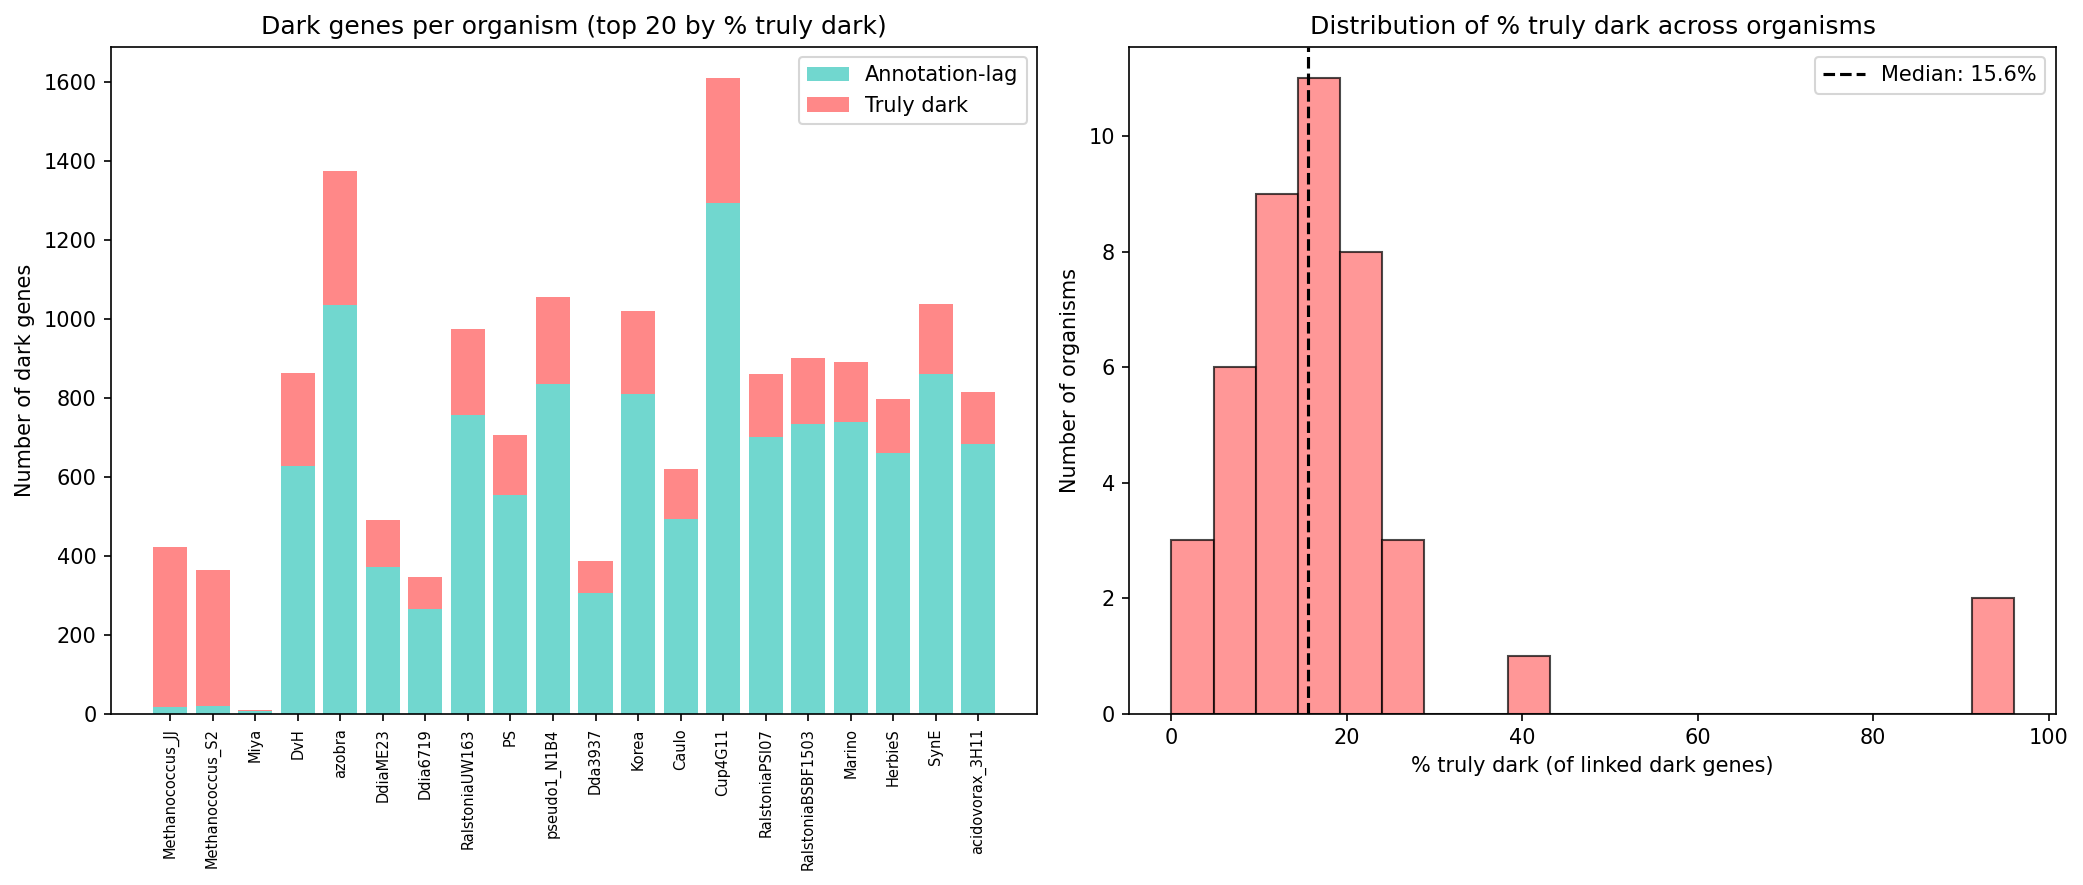

Saved: fig01_organism_distribution.png


In [6]:
# Organism distribution figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: counts per organism
top20 = org_counts.head(20)
ax = axes[0]
x = range(len(top20))
ax.bar(x, top20['annotation_lag'], label='Annotation-lag', color='#4ECDC4', alpha=0.8)
ax.bar(x, top20['truly_dark'], bottom=top20['annotation_lag'], label='Truly dark', color='#FF6B6B', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(top20.index, rotation=90, fontsize=7)
ax.set_ylabel('Number of dark genes')
ax.set_title('Dark genes per organism (top 20 by % truly dark)')
ax.legend()

# Right: histogram of % truly dark across organisms
ax = axes[1]
ax.hist(org_counts['pct_truly_dark'], bins=20, color='#FF6B6B', alpha=0.7, edgecolor='black')
ax.axvline(org_counts['pct_truly_dark'].median(), color='black', linestyle='--', label=f'Median: {org_counts["pct_truly_dark"].median():.1f}%')
ax.set_xlabel('% truly dark (of linked dark genes)')
ax.set_ylabel('Number of organisms')
ax.set_title('Distribution of % truly dark across organisms')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIG}/fig01_organism_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: fig01_organism_distribution.png')

## 5. Sequence Properties: Gene Length

In [7]:
# Gene length from the molecular_weight column as a proxy (bakta provides MW)
# Also check if census has length info from FB gene table
# The bakta_dark_gene_annotations has molecular_weight and isoelectric_point

# Convert MW to numeric
td['molecular_weight'] = pd.to_numeric(td['molecular_weight'], errors='coerce')
al['molecular_weight'] = pd.to_numeric(al['molecular_weight'], errors='coerce')

# MW is proportional to protein length (~110 Da per amino acid)
td['est_aa_length'] = td['molecular_weight'] / 110
al['est_aa_length'] = al['molecular_weight'] / 110

td_len = td['est_aa_length'].dropna()
al_len = al['est_aa_length'].dropna()

print(f'Truly dark — median estimated protein length: {td_len.median():.0f} aa (n={len(td_len):,})')
print(f'Annotation-lag — median estimated protein length: {al_len.median():.0f} aa (n={len(al_len):,})')

# Mann-Whitney U test
stat, pval = stats.mannwhitneyu(td_len, al_len, alternative='two-sided')
# Cohen's d
pooled_std = np.sqrt((td_len.std()**2 + al_len.std()**2) / 2)
cohens_d = (td_len.mean() - al_len.mean()) / pooled_std if pooled_std > 0 else 0

print(f'\nMann-Whitney U p = {pval:.2e}')
print(f'Cohen\'s d = {cohens_d:.3f}')
print(f'Truly dark are {"shorter" if cohens_d < 0 else "longer"} (effect size: {abs(cohens_d):.3f})')

# Short ORF check (< 50 aa ≈ 150 bp)
td_short = (td_len < 50).sum()
al_short = (al_len < 50).sum()
print(f'\nShort ORFs (< 50 aa / ~150 bp):')
print(f'  Truly dark: {td_short} ({td_short/len(td_len)*100:.1f}%)')
print(f'  Annotation-lag: {al_short} ({al_short/len(al_len)*100:.1f}%)')

Truly dark — median estimated protein length: 121 aa (n=6,406)
Annotation-lag — median estimated protein length: 194 aa (n=32,955)

Mann-Whitney U p = 0.00e+00
Cohen's d = -0.432
Truly dark are shorter (effect size: 0.432)

Short ORFs (< 50 aa / ~150 bp):
  Truly dark: 238 (3.7%)
  Annotation-lag: 137 (0.4%)


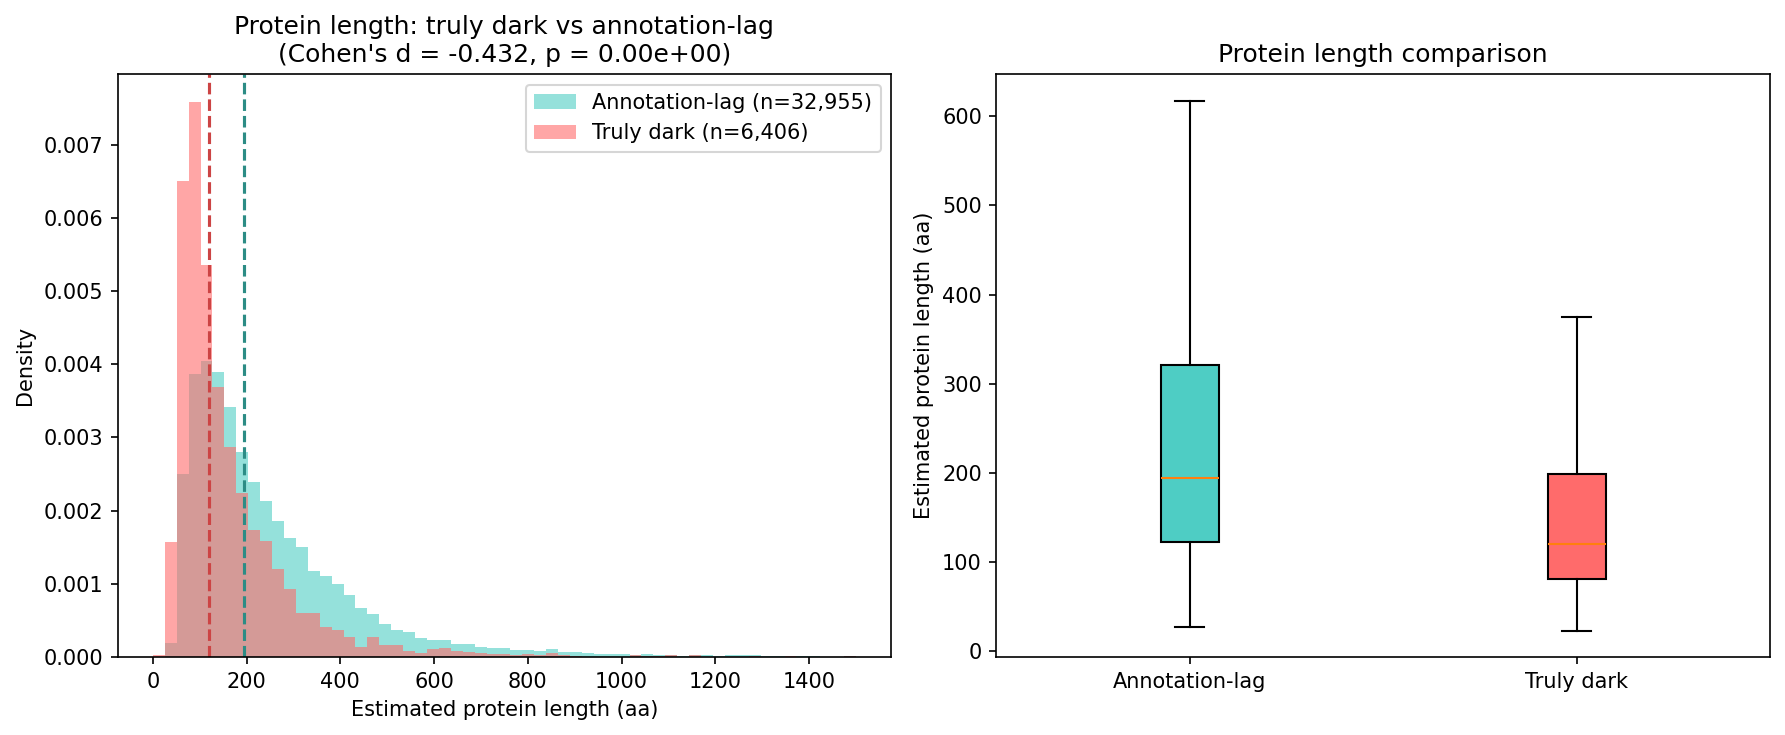

Saved: fig02_gene_length.png


In [8]:
# Gene length distribution figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: overlapping histograms
ax = axes[0]
bins = np.linspace(0, 1500, 60)
ax.hist(al_len, bins=bins, alpha=0.6, label=f'Annotation-lag (n={len(al_len):,})', color='#4ECDC4', density=True)
ax.hist(td_len, bins=bins, alpha=0.6, label=f'Truly dark (n={len(td_len):,})', color='#FF6B6B', density=True)
ax.axvline(al_len.median(), color='#2C8C85', linestyle='--', linewidth=1.5)
ax.axvline(td_len.median(), color='#CC4444', linestyle='--', linewidth=1.5)
ax.set_xlabel('Estimated protein length (aa)')
ax.set_ylabel('Density')
ax.set_title(f'Protein length: truly dark vs annotation-lag\n(Cohen\'s d = {cohens_d:.3f}, p = {pval:.2e})')
ax.legend()

# Right: box plot
ax = axes[1]
data = [al_len.values, td_len.values]
bp = ax.boxplot(data, labels=['Annotation-lag', 'Truly dark'], patch_artist=True, showfliers=False)
bp['boxes'][0].set_facecolor('#4ECDC4')
bp['boxes'][1].set_facecolor('#FF6B6B')
ax.set_ylabel('Estimated protein length (aa)')
ax.set_title('Protein length comparison')

plt.tight_layout()
plt.savefig(f'{FIG}/fig02_gene_length.png', bbox_inches='tight')
plt.show()
print('Saved: fig02_gene_length.png')

## 6. Conservation: Core vs Accessory vs Novel

In [9]:
# Load pangenome link table for conservation categories
link = pd.read_csv('../../../projects/conservation_vs_fitness/data/fb_pangenome_link.tsv', sep='\t')
print(f'FB-pangenome links: {len(link):,}')
print(f'Link columns: {link.columns.tolist()}')

# The link table has is_core, is_auxiliary, is_singleton as booleans
# Create a conservation_class column
def classify_conservation(row):
    if row.get('is_core', False) == True or str(row.get('is_core', '')).lower() == 'true':
        return 'core'
    elif row.get('is_singleton', False) == True or str(row.get('is_singleton', '')).lower() == 'true':
        return 'singleton'
    else:
        return 'accessory'

link['conservation_class'] = link.apply(classify_conservation, axis=1)
print(f'\nConservation class distribution in link table:')
print(link['conservation_class'].value_counts().to_string())

FB-pangenome links: 177,863
Link columns: ['orgId', 'locusId', 'gene_cluster_id', 'gtdb_species_clade_id', 'pident', 'evalue', 'bitscore', 'is_core', 'is_auxiliary', 'is_singleton']



Conservation class distribution in link table:
conservation_class
core         145821
accessory     24468
singleton      7574


In [10]:
# Merge conservation class onto truly dark and annotation-lag
cat_col = 'conservation_class'
td_cons = td.merge(link[['orgId', 'locusId', cat_col]], on=['orgId', 'locusId'], how='left')
al_cons = al.merge(link[['orgId', 'locusId', cat_col]], on=['orgId', 'locusId'], how='left')

print(f'Truly dark with conservation: {td_cons[cat_col].notna().sum()}/{len(td_cons)}')
print(f'Annotation-lag with conservation: {al_cons[cat_col].notna().sum()}/{len(al_cons)}')

Truly dark with conservation: 6427/6427
Annotation-lag with conservation: 33105/33105


In [11]:
# Conservation comparison
td_cat = td_cons[cat_col].value_counts(normalize=True).sort_index()
al_cat = al_cons[cat_col].value_counts(normalize=True).sort_index()

comp = pd.DataFrame({'truly_dark_%': (td_cat * 100).round(1),
                     'annotation_lag_%': (al_cat * 100).round(1)})
print('Conservation class distribution (%):')
print(comp.to_string())

# Fisher's exact for core vs non-core
td_core = (td_cons[cat_col] == 'core').sum()
td_noncore = len(td_cons) - td_core
al_core = (al_cons[cat_col] == 'core').sum()
al_noncore = len(al_cons) - al_core

table = [[td_core, td_noncore], [al_core, al_noncore]]
odds_ratio, fisher_p = stats.fisher_exact(table)
print(f'\nCore fraction — truly dark: {td_core/(td_core+td_noncore)*100:.1f}%, annotation-lag: {al_core/(al_core+al_noncore)*100:.1f}%')
print(f'Fisher\'s exact: OR = {odds_ratio:.3f}, p = {fisher_p:.2e}')

Conservation class distribution (%):
                    truly_dark_%  annotation_lag_%
conservation_class                                
accessory                   37.8              21.0
core                        43.1              72.7
singleton                   19.1               6.3

Core fraction — truly dark: 43.1%, annotation-lag: 72.7%
Fisher's exact: OR = 0.284, p = 0.00e+00


## 7. Essentiality Comparison

In [12]:
# Check essentiality from census data
td_ess = td['is_essential_dark'].sum()
al_ess = al['is_essential_dark'].sum()

td_ess_pct = td_ess / len(td) * 100
al_ess_pct = al_ess / len(al) * 100

# Fisher's exact
table = [[td_ess, len(td) - td_ess], [al_ess, len(al) - al_ess]]
or_ess, p_ess = stats.fisher_exact(table)

print(f'Essential genes:')
print(f'  Truly dark: {td_ess}/{len(td)} ({td_ess_pct:.1f}%)')
print(f'  Annotation-lag: {al_ess}/{len(al)} ({al_ess_pct:.1f}%)')
print(f'  Fisher\'s exact: OR = {or_ess:.3f}, p = {p_ess:.2e}')

Essential genes:
  Truly dark: 1157/6427 (18.0%)
  Annotation-lag: 4432/33105 (13.4%)
  Fisher's exact: OR = 1.420, p = 3.45e-21


## 8. Fitness Phenotype Comparison

In [13]:
# max_abs_fit: maximum absolute fitness value across all conditions
td['max_abs_fit'] = pd.to_numeric(td['max_abs_fit'], errors='coerce')
al['max_abs_fit'] = pd.to_numeric(al['max_abs_fit'], errors='coerce')

td_fit = td['max_abs_fit'].dropna()
al_fit = al['max_abs_fit'].dropna()

# Fraction with strong phenotype (|fitness| >= 2)
td_strong = (td_fit >= 2).sum()
al_strong = (al_fit >= 2).sum()

print(f'Max absolute fitness:')
print(f'  Truly dark — median: {td_fit.median():.2f}, mean: {td_fit.mean():.2f} (n={len(td_fit):,})')
print(f'  Annotation-lag — median: {al_fit.median():.2f}, mean: {al_fit.mean():.2f} (n={len(al_fit):,})')

stat, pval = stats.mannwhitneyu(td_fit, al_fit, alternative='two-sided')
pooled_std = np.sqrt((td_fit.std()**2 + al_fit.std()**2) / 2)
d_fit = (td_fit.mean() - al_fit.mean()) / pooled_std if pooled_std > 0 else 0
print(f'  Mann-Whitney p = {pval:.2e}, Cohen\'s d = {d_fit:.3f}')

print(f'\nStrong phenotype (|fitness| >= 2):')
print(f'  Truly dark: {td_strong}/{len(td_fit)} ({td_strong/len(td_fit)*100:.1f}%)')
print(f'  Annotation-lag: {al_strong}/{len(al_fit)} ({al_strong/len(al_fit)*100:.1f}%)')

table = [[td_strong, len(td_fit) - td_strong], [al_strong, len(al_fit) - al_strong]]
or_fit, p_fit = stats.fisher_exact(table)
print(f'  Fisher\'s exact: OR = {or_fit:.3f}, p = {p_fit:.2e}')

Max absolute fitness:
  Truly dark — median: 0.94, mean: 1.31 (n=5,270)
  Annotation-lag — median: 0.87, mean: 1.25 (n=28,673)
  Mann-Whitney p = 1.80e-06, Cohen's d = 0.051

Strong phenotype (|fitness| >= 2):
  Truly dark: 902/5270 (17.1%)
  Annotation-lag: 4677/28673 (16.3%)
  Fisher's exact: OR = 1.059, p = 1.51e-01


In [14]:
# Condition class enrichment for genes with strong phenotypes
td_cond = td.loc[td['max_abs_fit'] >= 2, 'top_condition_class'].value_counts(normalize=True)
al_cond = al.loc[al['max_abs_fit'] >= 2, 'top_condition_class'].value_counts(normalize=True)

cond_comp = pd.DataFrame({
    'truly_dark_%': (td_cond * 100).round(1),
    'annotation_lag_%': (al_cond * 100).round(1)
}).fillna(0).sort_values('truly_dark_%', ascending=False)

print('Condition class distribution for genes with |fitness| >= 2:')
print(cond_comp.to_string())

Condition class distribution for genes with |fitness| >= 2:
                                  truly_dark_%  annotation_lag_%
top_condition_class                                             
stress                                    43.3              54.7
carbon source                             13.7              21.7
nitrogen source                           12.3               9.7
mixed community                            7.5               0.0
nutrient t2                                5.1               0.0
rich t2                                    5.0               0.0
plant                                      1.5               0.5
nutrient t1                                1.5               0.0
nutrient                                   1.2               1.0
motility                                   1.2               3.2
respiratory growth                         1.0               0.6
marine broth                               0.7               0.2
iron                          

## 9. ICA Module Membership

In [15]:
# Module membership from census
td_has_module = td['module_prediction'].notna().sum()
al_has_module = al['module_prediction'].notna().sum()

td_mod_pct = td_has_module / len(td) * 100
al_mod_pct = al_has_module / len(al) * 100

table = [[td_has_module, len(td) - td_has_module], [al_has_module, len(al) - al_has_module]]
or_mod, p_mod = stats.fisher_exact(table)

print(f'ICA module membership:')
print(f'  Truly dark: {td_has_module}/{len(td)} ({td_mod_pct:.1f}%)')
print(f'  Annotation-lag: {al_has_module}/{len(al)} ({al_mod_pct:.1f}%)')
print(f'  Fisher\'s exact: OR = {or_mod:.3f}, p = {p_mod:.2e}')

ICA module membership:
  Truly dark: 472/6427 (7.3%)
  Annotation-lag: 3406/33105 (10.3%)
  Fisher's exact: OR = 0.691, p = 7.24e-14


## 10. Darkness Tier Distribution

In [16]:
# Compare darkness tier distribution
# Use the original darkness tier (pre-bakta update) from census
tier_col = 'darkness_tier_original' if 'darkness_tier_original' in td.columns else 'darkness_tier'

td_tiers = td[tier_col].value_counts(normalize=True).sort_index()
al_tiers = al[tier_col].value_counts(normalize=True).sort_index()

tier_comp = pd.DataFrame({
    'truly_dark_%': (td_tiers * 100).round(1),
    'annotation_lag_%': (al_tiers * 100).round(1)
}).fillna(0)

print('Original darkness tier distribution (%):')
print(tier_comp.to_string())

Original darkness tier distribution (%):
                        truly_dark_%  annotation_lag_%
darkness_tier_original                                
T2_Twilight                     35.5              10.0
T3_Dusk                         43.1              26.9
T4_Penumbra                     20.4              57.7
T5_Dawn                          1.0               5.4


## 11. Partial Annotation Clues in Truly Dark Genes

In [17]:
# Even though bakta calls them hypothetical, they may have partial annotations
# Check UniRef50, UniRef90, UniParc, RefSeq from bakta_dark_gene_annotations

clue_cols = {
    'uniref50': 'UniRef50',
    'uniref90': 'UniRef90',
    'uniref100': 'UniRef100',
    'uniparc': 'UniParc',
    'refseq': 'RefSeq',
    'ec': 'EC number',
    'go': 'GO terms',
    'cog_id': 'COG ID',
    'kegg_orthology_id': 'KEGG KO'
}

print('Partial annotation coverage in truly dark genes:')
print(f'{"Annotation":<15} {"Count":>8} {"% of TD":>10}')
print('-' * 35)
for col, label in clue_cols.items():
    if col in td.columns:
        has = td[col].notna() & (td[col] != '') & (td[col] != 'None')
        count = has.sum()
        pct = count / len(td) * 100
        print(f'{label:<15} {count:>8,} {pct:>9.1f}%')

print(f'\nTotal truly dark genes: {len(td):,}')

Partial annotation coverage in truly dark genes:
Annotation         Count    % of TD
-----------------------------------
UniRef50           5,100      79.4%
UniRef90           4,442      69.1%
UniRef100          4,442      69.1%
UniParc            4,442      69.1%
RefSeq             4,010      62.4%
EC number              2       0.0%
GO terms               0       0.0%
COG ID                 1       0.0%
KEGG KO               13       0.2%

Total truly dark genes: 6,427


## 12. Multiple Testing Correction Summary

In [18]:
# Collect all p-values for BH-FDR correction
test_results = []

# Gene length
stat_len, p_len = stats.mannwhitneyu(td_len, al_len, alternative='two-sided')
test_results.append(('Gene length (MW)', p_len, cohens_d, 'Cohen\'s d'))

# Fitness magnitude
test_results.append(('Max fitness (MW)', pval, d_fit, 'Cohen\'s d'))

# Essentiality
test_results.append(('Essentiality (Fisher)', p_ess, or_ess, 'OR'))

# Strong phenotype
test_results.append(('Strong phenotype (Fisher)', p_fit, or_fit, 'OR'))

# Module membership
test_results.append(('Module membership (Fisher)', p_mod, or_mod, 'OR'))

# Conservation (if available)
if cat_col:
    test_results.append(('Core conservation (Fisher)', fisher_p, odds_ratio, 'OR'))

# BH-FDR correction
pvals = [r[1] for r in test_results]
reject, qvals, _, _ = multipletests(pvals, method='fdr_bh')

print(f'{"Test":<30} {"p-value":>12} {"q-value":>12} {"Effect":>10} {"Type":>10} {"Sig":>5}')
print('-' * 80)
for (name, p, effect, etype), q, sig in zip(test_results, qvals, reject):
    print(f'{name:<30} {p:>12.2e} {q:>12.2e} {effect:>10.3f} {etype:>10} {"*" if sig else "":>5}')

print(f'\n* = significant at FDR < 0.05')
print(f'Total tests: {len(test_results)}')

Test                                p-value      q-value     Effect       Type   Sig
--------------------------------------------------------------------------------
Gene length (MW)                   0.00e+00     0.00e+00     -0.432  Cohen's d     *
Max fitness (MW)                   1.80e-06     2.16e-06      0.051  Cohen's d     *
Essentiality (Fisher)              3.45e-21     6.90e-21      1.420         OR     *
Strong phenotype (Fisher)          1.51e-01     1.51e-01      1.059         OR      
Module membership (Fisher)         7.24e-14     1.09e-13      0.691         OR     *
Core conservation (Fisher)         0.00e+00     0.00e+00      0.284         OR     *

* = significant at FDR < 0.05
Total tests: 6


## 13. Unlinked Dark Genes Summary

In [19]:
# The 17,479 unlinked dark genes — characterize briefly
print(f'Unlinked dark genes: {len(unlinked):,}')
print(f'\nOrganism distribution:')
unl_per_org = unlinked.groupby('orgId').size().sort_values(ascending=False)
print(unl_per_org.head(10).to_string())

# Essentiality
unl_ess = unlinked['is_essential_dark'].sum()
print(f'\nEssential: {unl_ess}/{len(unlinked)} ({unl_ess/len(unlinked)*100:.1f}%)')

# Strong phenotype
unlinked['max_abs_fit'] = pd.to_numeric(unlinked['max_abs_fit'], errors='coerce')
unl_strong = (unlinked['max_abs_fit'] >= 2).sum()
print(f'Strong phenotype: {unl_strong}/{len(unlinked)} ({unl_strong/len(unlinked)*100:.1f}%)')

# Darkness tiers
print(f'\nDarkness tiers:')
print(unlinked['darkness_tier'].value_counts().to_string())

Unlinked dark genes: 17,479

Organism distribution:
orgId
Pedo557     1963
Cola        1579
Magneto     1390
Burk376     1261
Miya        1135
SB2B        1048
Dyella79    1038
azobra       937
Keio         779
Kang         647

Essential: 3968/17479 (22.7%)
Strong phenotype: 2208/17479 (12.6%)

Darkness tiers:
darkness_tier
T2_Twilight    6680
T3_Dusk        4439
T1_Void        4273
T4_Penumbra    2087


## 14. Summary Figure

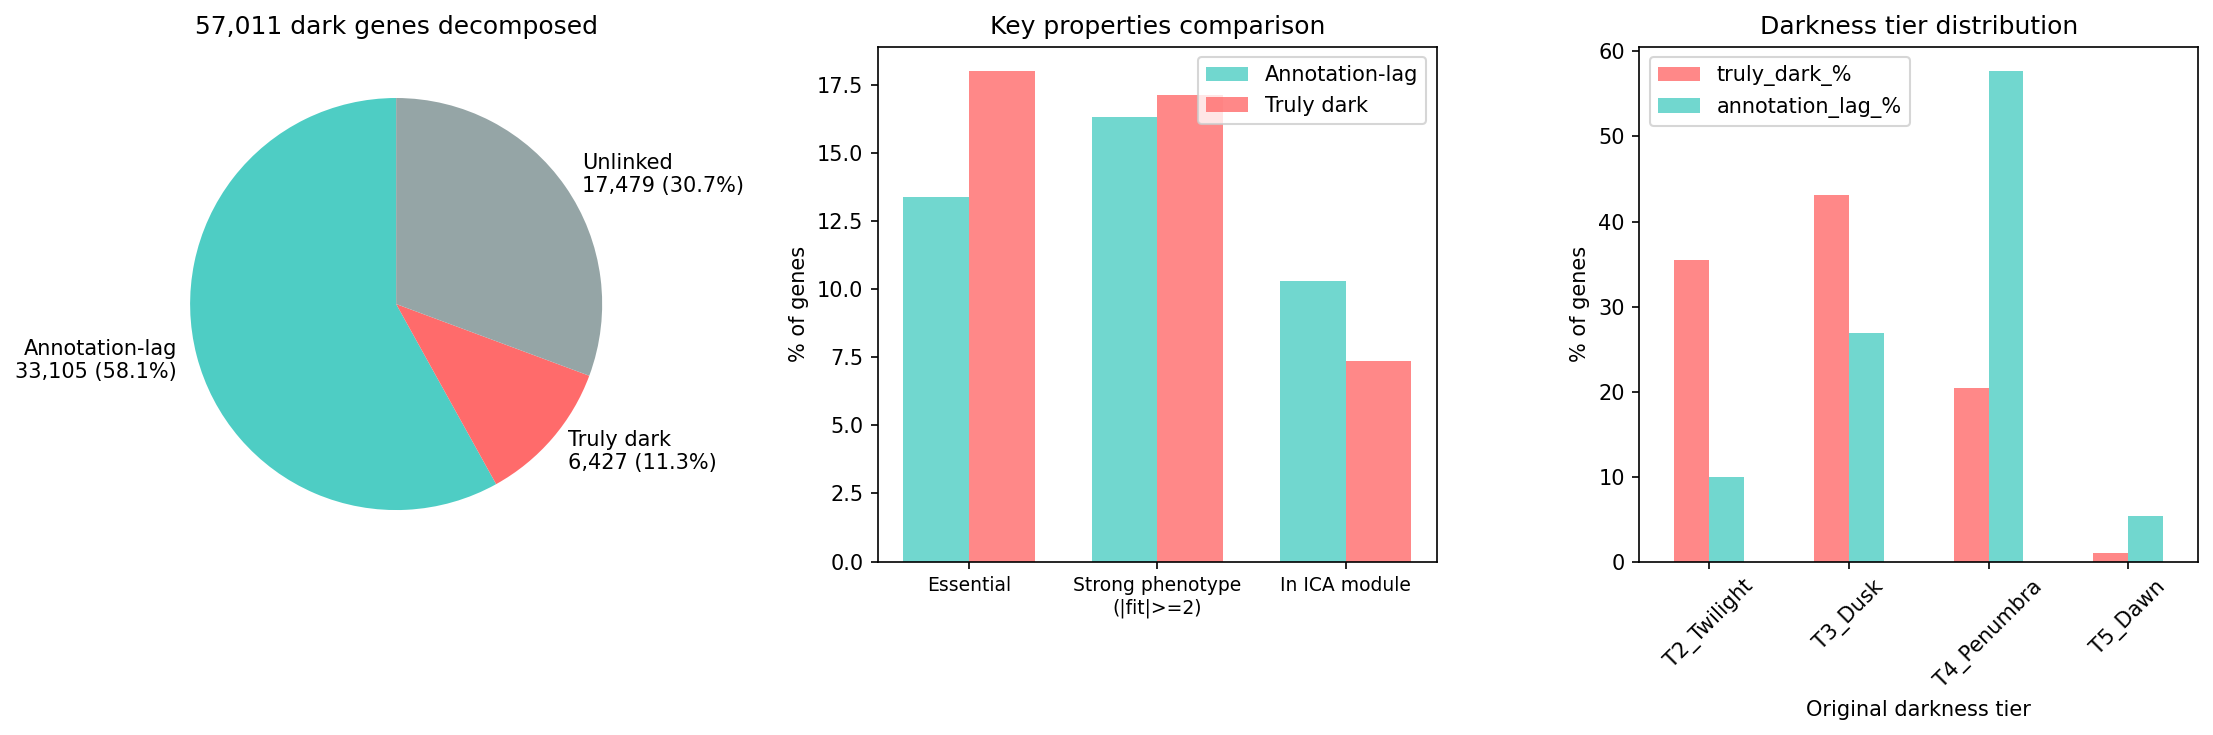

Saved: fig03_summary_comparison.png


In [20]:
# Summary figure: the dark matter decomposition
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Left: pie chart of dark gene categories
ax = axes[0]
sizes = [len(annotation_lag), len(truly_dark), len(unlinked)]
labels = [f'Annotation-lag\n{len(annotation_lag):,} ({len(annotation_lag)/len(census)*100:.1f}%)',
          f'Truly dark\n{len(truly_dark):,} ({len(truly_dark)/len(census)*100:.1f}%)',
          f'Unlinked\n{len(unlinked):,} ({len(unlinked)/len(census)*100:.1f}%)']
colors = ['#4ECDC4', '#FF6B6B', '#95A5A6']
ax.pie(sizes, labels=labels, colors=colors, autopct='', startangle=90)
ax.set_title(f'57,011 dark genes decomposed')

# Middle: comparison bars for key properties
ax = axes[1]
properties = ['Essential', 'Strong phenotype\n(|fit|>=2)', 'In ICA module']
td_vals = [td_ess_pct, td_strong/len(td_fit)*100, td_mod_pct]
al_vals = [al_ess_pct, al_strong/len(al_fit)*100, al_mod_pct]

x = np.arange(len(properties))
width = 0.35
ax.bar(x - width/2, al_vals, width, label='Annotation-lag', color='#4ECDC4', alpha=0.8)
ax.bar(x + width/2, td_vals, width, label='Truly dark', color='#FF6B6B', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(properties, fontsize=9)
ax.set_ylabel('% of genes')
ax.set_title('Key properties comparison')
ax.legend()

# Right: darkness tier comparison
ax = axes[2]
if len(tier_comp) > 0:
    tier_comp.plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
    ax.set_xlabel('Original darkness tier')
    ax.set_ylabel('% of genes')
    ax.set_title('Darkness tier distribution')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{FIG}/fig03_summary_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: fig03_summary_comparison.png')

## 15. Save Outputs

In [21]:
# Save truly dark gene list
td_out = td[['orgId', 'locusId', 'gene_cluster_id', 'desc', 'product',
              'uniref50', 'uniref90', 'uniparc', 'refseq',
              'molecular_weight', 'isoelectric_point', 'est_aa_length',
              'is_essential_dark', 'max_abs_fit', 'top_condition_class',
              'module_prediction', 'n_evidence_lines', 'composite_score']].copy()
td_out.to_csv(f'{OUT}/truly_dark_genes.tsv', sep='\t', index=False)
print(f'Saved: truly_dark_genes.tsv ({len(td_out):,} rows)')

# Save annotation-lag gene list
al_out = al[['orgId', 'locusId', 'gene_cluster_id', 'desc', 'product',
              'gene_bakta', 'ec', 'go', 'cog_id', 'cog_category',
              'kegg_orthology_id', 'uniref50',
              'is_essential_dark', 'max_abs_fit', 'top_condition_class',
              'module_prediction', 'n_evidence_lines', 'composite_score']].copy()
al_out.to_csv(f'{OUT}/annotation_lag_genes.tsv', sep='\t', index=False)
print(f'Saved: annotation_lag_genes.tsv ({len(al_out):,} rows)')

# Save unlinked dark genes
unlinked.to_csv(f'{OUT}/unlinked_dark_genes.tsv', sep='\t', index=False)
print(f'Saved: unlinked_dark_genes.tsv ({len(unlinked):,} rows)')

# Save organism-level summary
org_counts.to_csv(f'{OUT}/organism_summary.tsv', sep='\t')
print(f'Saved: organism_summary.tsv ({len(org_counts)} organisms)')

print(f'\n=== NB01 Complete ===')
print(f'Truly dark: {len(td_out):,} genes across {td_out["orgId"].nunique()} organisms')
print(f'Annotation-lag: {len(al_out):,} genes')
print(f'Unlinked: {len(unlinked):,} genes')

Saved: truly_dark_genes.tsv (6,427 rows)
Saved: annotation_lag_genes.tsv (33,105 rows)


Saved: unlinked_dark_genes.tsv (17,479 rows)
Saved: organism_summary.tsv (43 organisms)

=== NB01 Complete ===
Truly dark: 6,427 genes across 42 organisms
Annotation-lag: 33,105 genes
Unlinked: 17,479 genes
